# Solving a trajectory planning problem

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf

from robot_optimal_trajectory_planning.config import load_config
from robot_optimal_trajectory_planning.ModelBasedPlannerCasadi import ModelBasedPlannerCasadi

# make sure the package is installed correctly
# otherwise run `pip install .` from the directory robot_optimal_trajectory_planning

In [2]:
# generate a configuration

# load the default configuration
config = load_config(overrides=["solver=ipopt"])  # we use the solver ipopt in this example

# modify some settings
config.problem.sample_time = 0.1  # 0.1 seconds between discretization time steps
config.problem.prediction_horizon = 15  # plan 15 time steps into the future (1.5 s)
# the default solver options set by this package's config module priorizize speed over optimality,
# therefore we use IPOPT's own default solver options by passing IPOPT an empty dict
config.solver.solver_options = {}
# don't compile
config.solver.plugin_options["jit"] = False

print(OmegaConf.to_yaml(config))

defaults:
- _self_
- robot: ur5e
- solver: ipopt
robot:
  nx: 12
  nq: 6
  nu: 6
  q_min:
  - -6.283185307179586
  - -6.283185307179586
  - -6.283185307179586
  - -6.283185307179586
  - -6.283185307179586
  - -6.283185307179586
  q_max:
  - 6.283185307179586
  - 6.283185307179586
  - 6.283185307179586
  - 6.283185307179586
  - 6.283185307179586
  - 6.283185307179586
  dq_min:
  - -2.5132741228718345
  - -2.5132741228718345
  - -2.5132741228718345
  - -2.5132741228718345
  - -2.5132741228718345
  - -2.5132741228718345
  dq_max:
  - 2.5132741228718345
  - 2.5132741228718345
  - 2.5132741228718345
  - 2.5132741228718345
  - 2.5132741228718345
  - 2.5132741228718345
  u_min:
  - -12.566370614359172
  - -12.566370614359172
  - -12.566370614359172
  - -12.566370614359172
  - -12.566370614359172
  - -12.566370614359172
  u_max:
  - 12.566370614359172
  - 12.566370614359172
  - 12.566370614359172
  - 12.566370614359172
  - 12.566370614359172
  - 12.566370614359172
  collision_model: capsules
 

In [3]:
# create a planner object
planner = ModelBasedPlannerCasadi(config)

dt = config.problem.sample_time
H = config.problem.prediction_horizon

# generate a reference position trajectory
v = np.array([0.1, 0.5, 0.0])
p = np.array([0.35, 0.07, 0.10])
t = np.arange(H + 1) * dt  # includes current time (0 s) and all H future time steps
pos_ref = np.array([p + v * tt for tt in t]).T  # constant velocity prediction for the reference position
future_positions = pos_ref[:, 1:]  # the planner needs the reference starting at the first future time step

# constant orientation, given as unit quaternion
future_orientations = np.array([[1 / np.sqrt(2), 0, 0, 1 / np.sqrt(2)]] * H).T

# the planner takes references as numpy arrays of shape 3 x H for position and 4 x H for orientation
planner.set_reference(future_positions, future_orientations)

# set an initial state
initial_joint_angles = np.deg2rad([130, -60, 120, -60, -50, -180])  # 6 angles for 6 joints
initial_joint_velocities = np.zeros(6)  # assume robot starts at rest
x0 = np.concat((initial_joint_angles, initial_joint_velocities))  # the state consists of joint angles and velocities
planner.set_x0(x0)

In [4]:
# now solve the problem
planner.solve()


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      642
Number of nonzeros in inequality constraint Jacobian.:     5370
Number of nonzeros in Lagrangian Hessian.............:     4305

Total number of variables............................:      897
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      192
Total number of inequality c

In [5]:
# show the costs:
planner.get_debug_values()

OrderedDict([('cost', 11.643313440925056),
             ('cost_position_tracking', 1.981730920538983),
             ('cost_orientation_tracking', 0.191626645501302),
             ('cost_joint_velocities', 4.934880116617671),
             ('cost_joint_accelerations', 4.542556963989411),
             ('cost_tcp_acceleration', 0.0),
             ('cost_joint_angles', 0.0),
             ('cost_manipulability', 0.0),
             ('cost_slack', -0.007481205722309873),
             ('cost_collision_multipliers_regularization', 0.0)])

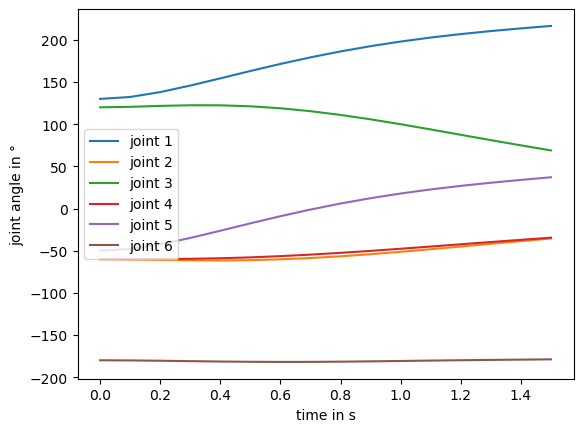

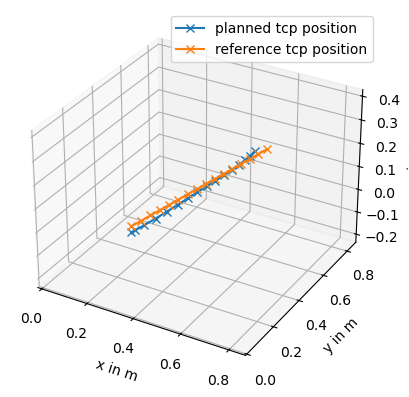

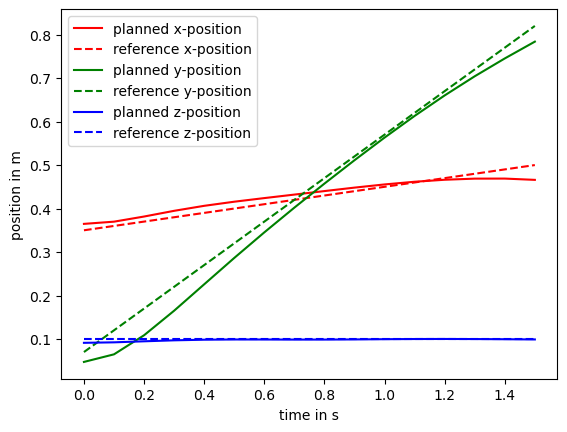

In [6]:
# now the solution can be retrieved from the planner object
x = planner.get_x_sol()
joint_angles = x[:6]
plt.figure()
for joint in range(6):
    plt.plot(t, np.rad2deg(joint_angles[joint, :]), label=f"joint {joint+1}")
plt.xlabel("time in s")
plt.ylabel("joint angle in °")
plt.legend()
plt.show()

pos = planner.get_r_sol()
ax = plt.figure().add_subplot(projection="3d")
ax.plot(pos[0, :], pos[1, :], pos[2, :], "x-", label="planned tcp position")
ax.plot(pos_ref[0, :], pos_ref[1, :], pos_ref[2, :], "x-", label="reference tcp position")
ax.legend()
ax.set_xlabel("x in m")
ax.set_ylabel("y in m")
ax.set_zlabel("z in m")
plt.axis("equal")
plt.show()

plt.figure()
for dim in range(3):
    plt.plot(t, pos[dim, :], "rgb"[dim], label="planned " + "xyz"[dim] + "-position")
    plt.plot(t, pos_ref[dim, :], "rgb"[dim] + "--", label="reference " + "xyz"[dim] + "-position")
plt.legend()
plt.xlabel("time in s")
plt.ylabel("position in m")
plt.show()

In [7]:
# we can also retrieve the end effector orientation as rotation matrices or quaternions
print("Rotation matrices")
print(planner.get_rotation_matrix_sol()[:3, :, :].round(2))
print("\nQuaternions")
print(planner.get_quat_sol()[:, :3].round(2))

Rotation matrices
[[[ 0.   -1.   -0.  ]
  [ 1.    0.   -0.  ]
  [ 0.    0.    1.  ]]

 [[-0.   -1.    0.  ]
  [ 1.   -0.   -0.  ]
  [ 0.    0.    1.  ]]

 [[-0.01 -1.    0.  ]
  [ 1.   -0.01 -0.01]
  [ 0.01  0.    1.  ]]]

Quaternions
[[ 0.71  0.71  0.7 ]
 [ 0.    0.    0.  ]
 [-0.   -0.   -0.  ]
 [ 0.71  0.71  0.71]]


In [8]:
# the solver object uses the stored solution for a warm start, so the next time solving is usually quicker
planner.solve()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      642
Number of nonzeros in inequality constraint Jacobian.:     5370
Number of nonzeros in Lagrangian Hessian.............:     4305

Total number of variables............................:      897
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      192
Total number of inequality constraints...............:     1005
        inequality constraints with only lower bounds:      735
   inequality constraints with lower and upper bounds:      270
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.1643313e+01 4.44e-16 2.33e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 